# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# cargar archivos
orders = pd.read_csv ("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv")
catalog = pd.read_csv ("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv")
marketing = pd.read_csv ("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")

In [3]:
# revisar el número de filas y columnas de cada dataset
print("orders", orders.shape)
print("catalog", catalog.shape)
print("marketing", marketing.shape)

orders (25100, 12)
catalog (7, 4)
marketing (1620, 5)


In [4]:
# explorar datasets
# tu código aquí
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [5]:
catalog.info()
catalog.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [6]:
marketing.info()
marketing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [7]:
# Conversion a fecha la columna `fecha_hora_pedido` de orders
date_convert = ["fecha_hora_pedido"]

for col in date_convert:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")
    orders = orders.dropna(subset=[col]).reset_index(drop=True)
orders["fecha_hora_pedido"].dt.year.value_counts().sort_index()

2025    25100
Name: fecha_hora_pedido, dtype: int64

In [8]:
# Conversion a fecha la columna `fecha` de marketing
date_convert = ["fecha"]

for col in date_convert:
    marketing[col] = pd.to_datetime(marketing[col], errors="coerce")
    marketing = marketing.dropna(subset=[col]).reset_index(drop=True)
marketing["fecha"].dt.year.value_counts().sort_index()

2025    1620
Name: fecha, dtype: int64

In [9]:
# Validar nulos totales y el porcentaje de las columnas
print(orders.isna().sum())
print(orders.isna().mean())

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64
id_pedido             0.000000
id_usuario            0.000000
fecha_hora_pedido     0.000000
pais                  0.011952
dispositivo           0.000797
fuente_referencia     0.001195
nombre_producto       0.001195
categoria_producto    0.003187
cantidad              0.001992
precio_unitario       0.001992
monto_descuento       0.001992
monto_total           0.000000
dtype: float64


In [10]:
# Variables Númericas de Orders
orders[["cantidad", "precio_unitario", "monto_descuento", "monto_total"]].describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [11]:
# Verificacion de variables númericas (Sentinels)
orders[["cantidad", "precio_unitario", "monto_descuento", "monto_total"]].le(0).sum()

cantidad               4
precio_unitario        0
monto_descuento    12551
monto_total            4
dtype: int64

In [12]:
# Reemplazar sentinels por la mediana en `cantidad` y `monto_total`
print(orders[["cantidad", "precio_unitario", "monto_total", "monto_descuento"]].value_counts().sort_index())

def reemplazar_ausentes (orders, sentinels, num_col):
    for col in num_col:
        orders[col] = orders[col].replace(sentinels, pd.NA)
    return orders
def rellenar_ausentes (orders, cols):
    for col in cols:
        orders[col] = pd.to_numeric(orders[col], errors="coerce")
        orders[col].fillna(orders[col].median(), inplace=True)
    return orders
def limpiar_orders(orders):
    valores_erroneos = [-2.0, -1.0, -192.62, -492.65, -423.53, -38.50, "", "<NA>", "nan"]
    columnas_nums = ["cantidad", "precio_unitario", "monto_total", "monto_descuento"]

    orders = reemplazar_ausentes(orders, valores_erroneos, columnas_nums)
    orders = rellenar_ausentes(orders, columnas_nums)
    return orders
orders = limpiar_orders(orders)
print(orders[["cantidad", "precio_unitario", "monto_total", "monto_descuento"]].value_counts().sort_index())

cantidad  precio_unitario  monto_total  monto_descuento
-2.0      101.31           -192.62      10.0               1
-1.0      43.50            -38.50       5.0                1
          423.53           -423.53      0.0                1
          497.65           -492.65      5.0                1
 1.0      20.06             15.06       5.0                1
                                                          ..
 10000.0  490.35            4903500.00  0.0                1
 20000.0  290.85            5817000.00  0.0                1
          297.66            5953200.00  0.0                1
          348.31            6966200.00  0.0                1
          442.01            8840200.00  0.0                1
Length: 24243, dtype: int64
cantidad  precio_unitario  monto_total  monto_descuento
1.0       20.06            15.06        5.0                1
                           20.06        0.0                1
          20.13            10.13        10.0               1
      

In [13]:
# Reemplazar valores nulos en columnas categoricas
print(orders["pais"].value_counts().sort_index())

# Convierte la primera letra de cada palabra en mayúscula
orders['pais'] = orders['pais'].str.title()

# Validar resultados 
print(orders['pais'].value_counts())

Argentina    7291
Colombia     7520
Mexico       7502
argentina     799
colombia      823
mexico        865
Name: pais, dtype: int64
Mexico       8367
Colombia     8343
Argentina    8090
Name: pais, dtype: int64


In [14]:

# Reemplazar espacios vacios por `Unknown` en columnas categóricas
def reemplazar_ausentes(orders, sentinels, obj_col):
    for col in obj_col:
        orders[col] = orders[col].str.strip().replace(sentinels, pd.NA)
    return orders
def rellenar_ausentes(orders, cols):
    for col in cols:
        orders[col] = orders[col].fillna("Unkwown")
    return orders
def limpiar_orders(orders):
    valores_erroneos = ["", "<NA>", "nan"]
    columnas_cats = ["pais","dispositivo","fuente_referencia","nombre_producto","categoria_producto"]

    orders = reemplazar_ausentes(orders, valores_erroneos, columnas_cats)
    orders = rellenar_ausentes(orders, columnas_cats)
    return orders
orders = limpiar_orders(orders)
# Verificar cambios
print(orders.isna().sum())
print(orders.isna().mean())


id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64
id_pedido             0.0
id_usuario            0.0
fecha_hora_pedido     0.0
pais                  0.0
dispositivo           0.0
fuente_referencia     0.0
nombre_producto       0.0
categoria_producto    0.0
cantidad              0.0
precio_unitario       0.0
monto_descuento       0.0
monto_total           0.0
dtype: float64


In [15]:
# Reemplazar espacios vacios por `Unknown` en canal de Marketing
def reemplazar_ausentes(marketing, sentinels, obj_col):
    for col in obj_col:
        marketing[col] = marketing[col].str.strip().replace(sentinels, pd.NA)
    return marketing
def rellenar_ausentes(marketing, cols):
    for col in cols:
        marketing[col] = marketing[col].fillna("Unkwown")
    return marketing
def limpiar_marketing(marketing):
    valores_erroneos = ["", "<NA>", "nan"]
    columnas_cats = ["canal"]

    marketing = reemplazar_ausentes(marketing, valores_erroneos, columnas_cats)
    marketing = rellenar_ausentes(marketing, columnas_cats)
    return marketing
marketing = limpiar_marketing(marketing)
# Verificar cambios
print(marketing.isna().sum())
print(marketing.isna().mean())

fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64
fecha         0.0
pais          0.0
id_campaña    0.0
canal         0.0
gasto         0.0
dtype: float64


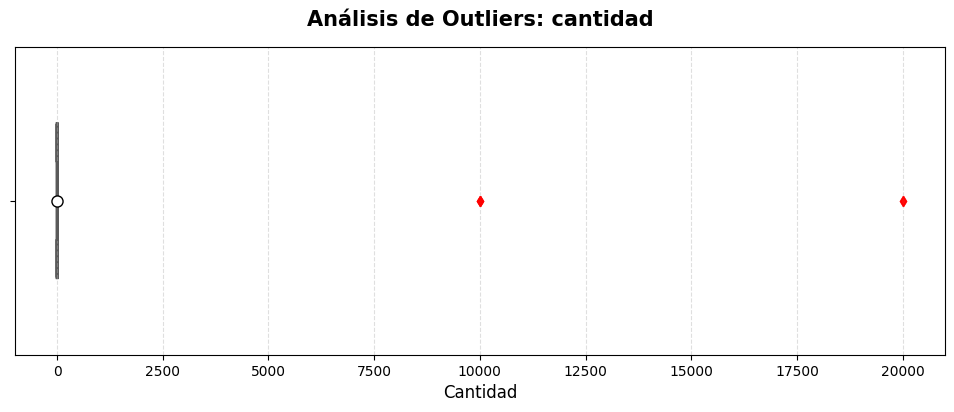

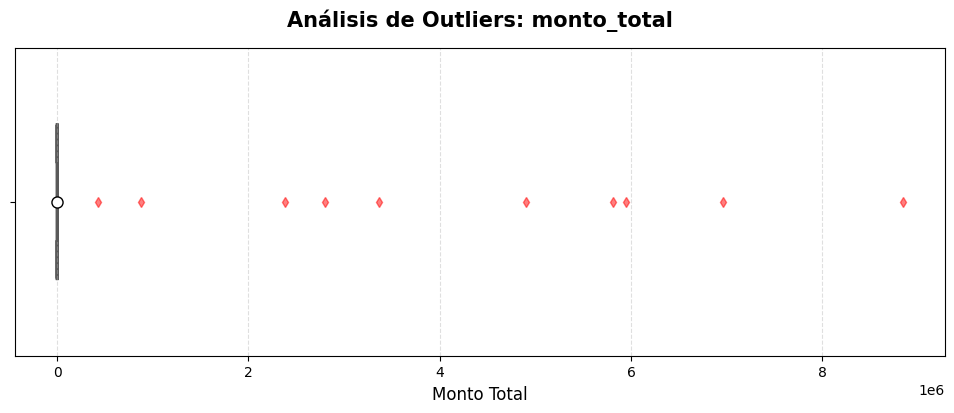

In [16]:
# Visualizando usando BoxPlot 
columnas_analizar = ['cantidad', "monto_total"]

# 2. Creamos el bucle for
for col in columnas_analizar:
    # Creamos una nueva figura para cada gráfico
    plt.figure(figsize=(12, 4))
    
    
    sns.boxplot(data=orders, x=col, 
                color='#79B486',      
                linewidth=2,           
                width=0.5,             
                notch=True,            
                showmeans=True,        
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                flierprops={"marker": "d", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5}) 
    
    plt.title(f'Análisis de Outliers: {col}', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    
    # Añadimos una cuadrícula sutil solo en el eje X para medir mejor los rangos
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.show()

In [17]:
cols_con_outliers = ['cantidad', "monto_total"]

for col in cols_con_outliers:
    # 1. Calculamos los cuartiles
    Q1 = orders[col].quantile(0.25)
    Q3 = orders[col].quantile(0.75)
    
    # 2. Calculamos el IQR
    IQR = Q3 - Q1
    
    # 3. Calculamos el límite superior (la valla)
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"--- Columna: {col} ---")
    print(f"Límite superior: {limite_superior}")
    
    # 4. ¿Cuántos outliers hay?
    outliers = orders[orders[col] > limite_superior]
    print(f"Cantidad de outliers detectados: {len(outliers)}")
    print("\n")

--- Columna: cantidad ---
Límite superior: 3.5
Cantidad de outliers detectados: 10


--- Columna: monto_total ---
Límite superior: 1025.5387500000002
Cantidad de outliers detectados: 10




In [18]:
# Filtramos los outliers
orders = orders[
    (orders['cantidad'] <= 3.5) &
    (orders['monto_total'] <= 1025.5)
].copy()

print(f"Usuarios después de la limpieza: {len(orders)}")

Usuarios después de la limpieza: 25090


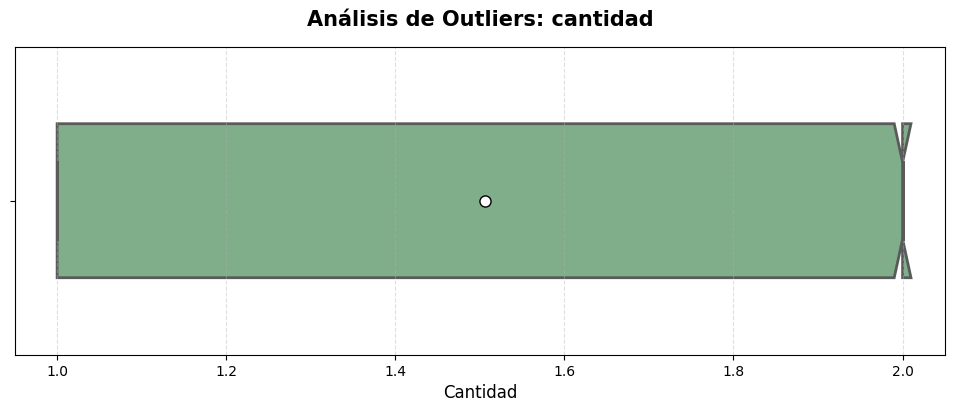

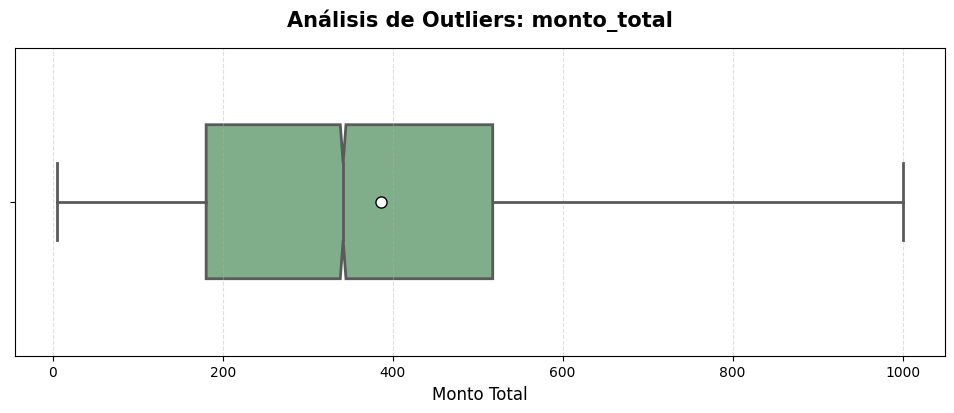

In [19]:
# Visualizando usando BoxPlot 
columnas_analizar = ['cantidad', "monto_total"]

# 2. Creamos el bucle for
for col in columnas_analizar:
    # Creamos una nueva figura para cada gráfico
    plt.figure(figsize=(12, 4))
    
    
    sns.boxplot(data=orders, x=col, 
                color='#79B486',      
                linewidth=2,           
                width=0.5,             
                notch=True,            
                showmeans=True,        
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                flierprops={"marker": "d", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5}) 
    
    plt.title(f'Análisis de Outliers: {col}', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    
    # Añadimos una cuadrícula sutil solo en el eje X para medir mejor los rangos
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.show()



In [20]:

def validar_consistencia_montos(orders):
    # Clonamos para trabajar de forma segura sin alterar la data original
    df_audit = orders.copy()
    
    # Ecuación de control matemático (Operación vectorizada en Pandas)
    monto_calculado = (df_audit['cantidad'] * df_audit['precio_unitario']) - df_audit['monto_descuento']
    
    # Medimos la diferencia absoluta
    df_audit['diferencia'] = (df_audit['monto_total'] - monto_calculado).abs()
    
    # Filtramos las inconsistencias (tolerancia de 0.01 para decimales flotantes)
    inconsistencias = df_audit[df_audit['diferencia'] > 0.01]
    
    return inconsistencias


def pipeline_verificacion_montos(orders):
    
    # Ejecutamos la función de auditoría pasándole 'orders'
    df_errores_monto = validar_consistencia_montos(orders)
    total_errores = len(df_errores_monto)
    
    # Evaluamos los resultados para dar el diagnóstico
    print("--------------------------------------------------")
    print(f"📊 REPORTE DE CONSISTENCIA FINANCIERA")
    print(f"• Total de registros evaluados: {len(orders)}")
    print(f"• Registros con montos inconsistentes: {total_errores}")
    print("--------------------------------------------------")
    
    if total_errores > 0:
        print(f"⚠️ Alerta: Se detectó un {(total_errores / len(orders)) * 100:.2f}% de inconsistencias en los montos.")
        print("Sugerencia: Revisa el DataFrame devuelto para inspeccionar las filas afectadas.")
    else:
        print("¡Perfecto! El 100% de los montos es consistente con la regla de negocio.")
        
    print("\nPipeline ejecutado con éxito.")
    
    # Retornamos el DataFrame de los errores para que los puedas visualizar
    return df_errores_monto

# Llamas al pipeline pasándole tu DataFrame original 'orders'
ordenes_inconsistentes = pipeline_verificacion_montos(orders)

# Si el reporte te dice que hay errores, visualizas el desglose aquí:
if len(ordenes_inconsistentes) > 0:
    display(ordenes_inconsistentes[['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']].head())


--------------------------------------------------
📊 REPORTE DE CONSISTENCIA FINANCIERA
• Total de registros evaluados: 25090
• Registros con montos inconsistentes: 1200
--------------------------------------------------
⚠️ Alerta: Se detectó un 4.78% de inconsistencias en los montos.
Sugerencia: Revisa el DataFrame devuelto para inspeccionar las filas afectadas.

Pipeline ejecutado con éxito.


,cantidad,precio_unitario,monto_descuento,monto_total
2,2.0,102.990,10.0,195.99
24,2.0,117.990,0.0,235.99
35,2.0,467.340,5.0,929.69
41,2.0,37.770,10.0,65.53
74,2.0,258.715,0.0,595.85


In [21]:
def corregir_montos_orders(orders):
    
    # Creamos una copia para trabajar de forma segura
    orders_corregido = orders.copy()
    
    # Aplicamos la fórmula matemática exacta
    monto_exacto = (orders_corregido['cantidad'] * orders_corregido['precio_unitario']) - orders_corregido['monto_descuento']
    
    # Reemplazamos la columna original
    orders_corregido['monto_total'] = monto_exacto
    
    print("✅ ¡Montos corregidos! Se eliminaron los desajustes de redondeo.")
    return orders_corregido

# Se aplica la corrección al DataFrame principal
orders = corregir_montos_orders(orders)

✅ ¡Montos corregidos! Se eliminaron los desajustes de redondeo.


In [22]:
ordenes_inconsistentes = pipeline_verificacion_montos(orders)

indices_clave = [2, 24, 35, 74]
display(orders.loc[indices_clave, ['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']])

--------------------------------------------------
📊 REPORTE DE CONSISTENCIA FINANCIERA
• Total de registros evaluados: 25090
• Registros con montos inconsistentes: 0
--------------------------------------------------
¡Perfecto! El 100% de los montos es consistente con la regla de negocio.

Pipeline ejecutado con éxito.


,cantidad,precio_unitario,monto_descuento,monto_total
2,2.0,102.990,10.0,195.98
24,2.0,117.990,0.0,235.98
35,2.0,467.340,5.0,929.68
74,2.0,258.715,0.0,517.43


In [23]:
# Eliminamos los duplicados basados en el ID del pedido y plasmamos el cambio
orders = orders.drop_duplicates(subset=['id_pedido'], keep='first')
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24990 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24990 non-null  object        
 1   id_usuario          24990 non-null  object        
 2   fecha_hora_pedido   24990 non-null  datetime64[ns]
 3   pais                24990 non-null  object        
 4   dispositivo         24990 non-null  object        
 5   fuente_referencia   24990 non-null  object        
 6   nombre_producto     24990 non-null  object        
 7   categoria_producto  24990 non-null  object        
 8   cantidad            24990 non-null  float64       
 9   precio_unitario     24990 non-null  float64       
 10  monto_descuento     24990 non-null  float64       
 11  monto_total         24990 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.5+ MB


 **Reporte Técnico de Calidad y Preparación de Datos (ETL)**

Antes de proceder con el modelado visual y la creación de KPIs estratégicos, se ejecutó una fase rigurosa de ETL (Extracción, Transformación y Carga) en Python para garantizar la integridad y gobernanza de los datos mediante los siguientes hitos:

**1. Validación Cronológica**
Se estandarizaron las cadenas de texto de las fechas, convirtiéndolas al tipo de dato correcto `datetime64`. Esto solucionó problemas de inconsistencia en los formatos y permitió habilitar los análisis de inteligencia de tiempo (como el cálculo del Revenue YTD) sin desajustes temporales.

**2. Gobernanza de Variables Numéricas**
Se realizó una auditoría de valores atípicos en las métricas cuantitativas, asegurando que columnas críticas como cantidad no contuvieran valores negativos o registros en cero que distorsionaran el cálculo del Ticket Promedio o las unidades totales vendidas.

**3. Consistencia de Montos Financieros**
Se cruzó la información de transacciones y catálogos, detectando que ciertas métricas operativas (como el costo_unitario) debían mapearse correctamente por relación en el modelo para evitar la duplicidad artificial de costos generales en el desglose por producto.

**4. Depuración de Duplicados**
Se aplicaron filtros de detección para registros idénticos y transacciones redundantes en la tabla de órdenes limpias, garantizando que cada fila represente un evento único y real de compra.

**5. Normalización Categórica**
Se inspeccionaron las variables de texto (como los nombres de productos y países), identificando y aislando registros con inconsistencias de origen (como el caso de la categoría `Unknown`) para mantener la transparencia del reporte sin alterar el volumen general de ingresos.

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [24]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [25]:
# 1. Revenue total (Suma de monto_total en orders)
revenue_total = orders['monto_total'].sum()

In [26]:
# 2. Costo total de productos
orders_with_cost = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')

orders_with_cost['costo_pedido'] = orders_with_cost['cantidad'] * orders_with_cost['costo_unitario']
costo_total_productos = orders_with_cost['costo_pedido'].sum()

In [27]:
# 3. Inversión en marketing (Suma de gasto en marketing_spend)
inversion_marketing = marketing['gasto'].sum()

In [28]:
# 4. Ganancia Bruta (Revenue - Costo de productos)
ganancia_bruta = revenue_total - costo_total_productos

In [29]:
# 5. Ganancia Neta (Revenue - Costo de productos - Marketing)
ganancia_neta = revenue_total - costo_total_productos - inversion_marketing

In [30]:
# 6. Margen de ganancia (Ganancia neta / Revenue * 100)
margen_ganancia = (ganancia_neta / revenue_total) * 100

In [31]:
print("=" * 45)
print("         KPIs DE RENTABILIDAD GENERAL        ")
print("=" * 45)
print(f"Revenue Total         : ${revenue_total:,.2f}")
print(f"Costo Total Productos : ${costo_total_productos:,.2f}")
print(f"Inversión Marketing   : ${inversion_marketing:,.2f}")
print("-" * 45)
print(f"Ganancia Bruta        : ${ganancia_bruta:,.2f}")
print(f"Ganancia Neta         : ${ganancia_neta:,.2f}")
print(f"Margen de Ganancia    : {margen_ganancia:.2f}%")
print("=" * 45)

         KPIs DE RENTABILIDAD GENERAL        
Revenue Total         : $9,650,265.85
Costo Total Productos : $3,837,207.45
Inversión Marketing   : $2,871,843.53
---------------------------------------------
Ganancia Bruta        : $5,813,058.40
Ganancia Neta         : $2,941,214.87
Margen de Ganancia    : 30.48%


In [32]:
# 1. ¿Cuál es el ticket promedio por orden?
ticket_promedio = orders.groupby('id_pedido')['monto_total'].sum().mean()
print(f"Ticket Promedio por Orden          : ${ticket_promedio:,.2f}")

Ticket Promedio por Orden          : $386.17


In [33]:
# 2. ¿Cuál es la cantidad promedio de productos por orden?
cant_promedio_orden = orders.groupby('id_pedido')['cantidad'].sum().mean()
print(f"Cantidad Promedio por Orden        : {cant_promedio_orden:.1f} productos")
print("-" * 55)

Cantidad Promedio por Orden        : 1.5 productos
-------------------------------------------------------


In [34]:
# 3. ¿Cuál es el producto más vendido?

producto_top = orders.groupby('nombre_producto')['cantidad'].sum().idxmax()
cantidad_top = orders.groupby('nombre_producto')['cantidad'].sum().max()
print(f"Producto Más Vendido       : {producto_top} ({cantidad_top:,} unidades)")
print("-" * 55)

Producto Más Vendido       : Vacuum-Pro-Black (6,296.0 unidades)
-------------------------------------------------------


In [35]:
# 4. ¿Cuánto se ha gastado en marketing por canal?
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

print("📌 Gasto Total en Marketing por Canal:")
for canal, gasto in gasto_por_canal.items():
    print(f"  • {canal:<15}: ${gasto:,.2f}")
print("=" * 55)

📌 Gasto Total en Marketing por Canal:
  • social         : $918,043.21
  • organic        : $913,533.01
  • paid_search    : $863,088.21
  • Unkwown        : $177,179.10


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [36]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [37]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [38]:
# PARTE 1: Totales del funnel
# ======================


query_totals = '''

WITH cte_visit AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'
),
cte_cart AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'
),
cte_payment AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
)
SELECT
    COUNT(v.id_usuario) AS users_first_visit,
    COUNT(c.id_usuario) AS users_add_cart,
    COUNT(p.id_usuario) AS users_payment,
    COUNT(pur.id_usuario) AS users_purchase
FROM cte_visit v 
LEFT JOIN cte_cart c 
    ON v.id_usuario = c.id_usuario
LEFT JOIN cte_payment p 
    ON c.id_usuario = p.id_usuario
LEFT JOIN cte_purchase pur 
    ON p.id_usuario = pur.id_usuario
'''

totals = pd.read_sql(query_totals, con=engine)
totals


,users_first_visit,users_add_cart,users_payment,users_purchase
0,7796,7439,5799,4500


In [39]:

# PARTE 2: Conversiones
# ======================


query_conversion = '''
WITH cte_visit AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'first_visit'
),
cte_cart AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_to_cart'
),
cte_payment AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
    SELECT DISTINCT id_usuario
    FROM events
    WHERE nombre_evento = 'purchase'
),

funnel_counts AS(
    SELECT
        COUNT(v.id_usuario) AS users_first_visit,
        COUNT(c.id_usuario) AS users_add_cart,
        COUNT(p.id_usuario) AS users_payment,
        COUNT(pur.id_usuario) AS users_purchase
    FROM cte_visit v 
        LEFT JOIN cte_cart c 
            ON v.id_usuario = c.id_usuario
        LEFT JOIN cte_payment p 
            ON c.id_usuario = p.id_usuario
        LEFT JOIN cte_purchase pur 
            ON p.id_usuario = pur.id_usuario
) 

SELECT
    -- Conversion Absoluta
    ROUND(users_add_cart * 100.0 / users_first_visit, 2) AS conv_abs_add_cart,
    ROUND(users_payment * 100.0 / users_first_visit, 2) AS conv_abs_payment,
    ROUND(users_purchase * 100.0 / users_first_visit, 2) AS conv_abs_purchase,
    -- Conversión paso a paso 
    ROUND(users_add_cart * 100.0 / users_first_visit, 2) AS conv_paso_add_cart,
    ROUND(users_payment * 100.0 / NULLIF(users_add_cart, 0), 2) AS conv_paso_payment,
    ROUND(users_purchase * 100.0 / NULLIF(users_payment, 0), 2) AS conv_paso_purchase
FROM funnel_counts;

'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion


,conv_abs_add_cart,conv_abs_payment,conv_abs_purchase,conv_paso_add_cart,conv_paso_payment,conv_paso_purchase
0,95.42,74.38,57.72,95.42,77.95,77.6


**Análisis del Funnel de Conversión y Comportamiento del Usuario**

A partir de las métricas obtenidas mediante la consulta SQL, se evalúa el flujo de comportamiento de los usuarios únicos en las cuatro etapas esenciales del proceso de compra:

**1. Volumen de Usuarios por Etapa**
* **Primera visita (users_first_visit):** 7,796 usuarios ingresaron a la plataforma.
* **Añadir al carrito (users_add_cart):** 7,439 usuarios seleccionaron al menos un producto.
* **Pantalla de pago (users_payment):** 5,799 usuarios iniciaron el proceso de checkout.
* **Compra exitosa (users_purchase):** 4,500 usuarios completaron la transacción.

**2. Tasas de Conversión Paso a Paso (Conversión Relativa)**
* **De Visita a Carrito (conv_paso_add_cart):** 95.42%. Existe un enganche inicial excelente; la gran mayoría de los visitantes muestra intención de compra.
* **De Carrito a Pago (conv_paso_payment):** 77.95%. Aquí se genera la primera fricción importante, donde un 22.05% de los usuarios abandona el carrito antes de pasar a la pasarela de pagos.
* **De Pago a Compra (conv_paso_purchase):** 77.60%. Un 22.40% de los usuarios que ya tenían la intención de pagar e ingresaron sus datos no logran o no finalizan la compra.

**3. Conversión Final Absoluta**
* **Tasa de Conversión Total (conv_abs_purchase):** 57.72%. 

**Conclusión Estratégica**
El embudo muestra una salud general robusta con una conversión final muy alta (más de la mitad de los visitantes iniciales compran). Sin embargo, los puntos críticos de fuga ocurren en las transiciones intermedias y finales. Se recomienda auditar la estabilidad de la pasarela de pagos y evaluar posibles fricciones en el checkout (como costos de envío inesperados o formularios complejos) que expliquen la pérdida combinada de casi 3,000 usuarios entre el carrito y la confirmación de compra.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [40]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [41]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT * 
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [42]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohorte AS(
    SELECT 
        id_usuario,
        CAST(DATE_TRUNC('month', CAST(MIN(fecha_registro) AS TIMESTAMP)) AS DATE) AS cohorte
    FROM users
    GROUP BY id_usuario
),
actividad AS(
    SELECT 
        ua.id_usuario,
        c.cohorte,
        ua.dias_despues_registro,
        ua.activo
    FROM user_activity AS ua
    LEFT JOIN cohorte AS c
        ON ua.id_usuario = c.id_usuario
)
SELECT
    cohorte,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7 AND activo = 1 THEN id_usuario END) AS retenido_w1,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14 AND activo = 1 THEN id_usuario END) AS retenido_w2,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 21 AND activo = 1 THEN id_usuario END) AS retenido_w3,
    COUNT(DISTINCT CASE WHEN dias_despues_registro >= 28 AND activo = 1 THEN id_usuario END) AS retenido_w4,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro >= 7 AND activo = 1 THEN id_usuario END)/
    NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_1,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro >= 14 AND activo = 1 THEN id_usuario END)/
    NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_2,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro >= 21 AND activo = 1 THEN id_usuario END)/
    NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_3,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN dias_despues_registro >= 28 AND activo = 1 THEN id_usuario END)/
    NULLIF(COUNT(DISTINCT id_usuario), 0), 1) AS semana_4
FROM actividad  
GROUP BY cohorte
ORDER BY cohorte

'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,retenido_w1,retenido_w2,retenido_w3,retenido_w4,semana_1,semana_2,semana_3,semana_4
0,2025-01-01,1381,1253,1027,671,84.9,77.0,63.1,41.2
1,2025-02-01,1255,1154,940,575,86.9,79.9,65.1,39.8
2,2025-03-01,1428,1306,1060,673,87.3,79.8,64.8,41.1
3,2025-04-01,1394,1261,1022,652,86.8,78.5,63.6,40.6
4,2025-05-01,1446,1321,1088,679,85.7,78.3,64.5,40.2


**Análisis de Retención por Cohortes Semanales**

A partir de los datos procesados, se analiza el comportamiento de permanencia de los usuarios registrados entre enero y mayo de 2025, midiendo cuántos de ellos se mantienen activos durante sus primeras cuatro semanas (w1 a w4).

**1. Comportamiento de las Cohortes (Volumen de Usuarios)**
El volumen de usuarios retenidos en la primera semana (`retenido_w1`) se mantiene muy estable mes a mes, oscilando entre los 1,255 usuarios (cohorte de febrero) y los 1,446 usuarios (cohorte de mayo). Esto demuestra un flujo constante en la adquisición de clientes.

**2. Dinámica de la Tasa de Retención Semanal**
Al evaluar los porcentajes de retención, se identifica un patrón de comportamiento idéntico en todos los grupos:

* **Semana 1:** Registra una retención sólida de entre el 84.9% y el 87.3%. La gran mayoría de los usuarios regresa a la plataforma inmediatamente después del registro.
* **Semana 2:** Se experimenta una caída gradual, situando la retención en torno al 77.0% - 79.9%.
* **Semana 3:** La métrica desciende a niveles de entre 63.1% y 65.1%.
* **Semana 4:** Al cumplirse el primer mes, la retención se estabiliza alrededor del 39.8% - 41.2% para todas las cohortes.

**Conclusión Estratégica**
El negocio tiene una retención sumamente consistente; no hay variaciones drásticas entre los meses analizados, lo que indica que los cambios estacionales o las campañas de marketing no alteran el ciclo de vida del usuario una vez dentro. 

Sin embargo, el punto crítico se encuentra entre la Semana 3 y la Semana 4, donde se pierde aproximadamente el 23% de los usuarios activos remanentes (pasando de un ~64% a un ~40%). Se sugiere implementar estrategias de reactivación y engagement específicas (notificaciones push, promociones exclusivas o programas de lealtad) orientadas a los usuarios que cumplen sus primeros 20 días de registro para mitigar esta caída de fin de mes.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---

### Prueba z 

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia estadísticamente significativa en la tasa de conversion de los usuarios entre la página control y la página tratamiento
- **Hipótesis alternativa (H₁):** Existe una diferencia estadísticamente significativa en la tasa de conversion de los usuarios entre la página control y la página tratamiento

**Nivel de significancia alpha:** Umbral de significancia estandar de 0.05 

In [43]:
# tu código aquí
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [44]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [45]:
experiment["id_usuario"].nunique()

10000

In [46]:
date_drop_cols = ["timestamp"]

for col in date_drop_cols:
    experiment[col] = pd.to_datetime(experiment[col], errors="coerce")
    experiment = experiment.dropna(subset=[col]).reset_index(drop=True)

experiment.info() # Validación del Cambio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_usuario       10000 non-null  object        
 1   variante         10000 non-null  object        
 2   convirtio        10000 non-null  int64         
 3   dispositivo      10000 non-null  object        
 4   pais             10000 non-null  object        
 5   duracion_sesion  10000 non-null  float64       
 6   timestamp        10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 547.0+ KB


In [47]:
# Identificar rango temporal del experimento
print("Fecha mínima:", experiment["timestamp"].min())
print("Fecha máxima:", experiment["timestamp"].max())

Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-06-30 00:00:00


In [48]:
experiment["duracion_sesion"].describe()

count    10000.000000
mean       159.862439
std         81.074410
min         20.010000
25%         89.470000
50%        159.725000
75%        229.745000
max        300.000000
Name: duracion_sesion, dtype: float64

In [49]:
# Resumen estadístico de usuarios que se convirtieron
resumen_conversion = experiment["convirtio"].describe()
print(resumen_conversion)

count    10000.000000
mean         0.159900
std          0.366532
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: convirtio, dtype: float64


In [50]:
experiment[experiment["convirtio"] == 1].describe()

,convirtio,duracion_sesion
count,1599.0,1599.000000
mean,1.0,160.180256
std,0.0,82.445774
min,1.0,20.350000
25%,1.0,85.440000
50%,1.0,160.230000
75%,1.0,231.995000
max,1.0,299.590000


In [51]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ["variante", "pais", "dispositivo"]:
    print("\n")
    print(f"--- Distribución de {col} ---")
    print(experiment[col].value_counts())
    print(f"--- Porcentaje de {col} ---")
    print(experiment[col].value_counts(normalize=True) * 100) # Porcentaje
    print("\n")


Conteo de categorías:


--- Distribución de variante ---
tratamiento    5035
control        4965
Name: variante, dtype: int64
--- Porcentaje de variante ---
tratamiento    50.35
control        49.65
Name: variante, dtype: float64




--- Distribución de pais ---
Mexico       3405
Argentina    3317
Colombia     3278
Name: pais, dtype: int64
--- Porcentaje de pais ---
Mexico       34.05
Argentina    33.17
Colombia     32.78
Name: pais, dtype: float64




--- Distribución de dispositivo ---
desktop    5042
mobile     4958
Name: dispositivo, dtype: int64
--- Porcentaje de dispositivo ---
desktop    50.42
mobile     49.58
Name: dispositivo, dtype: float64




In [52]:
# Número de usuarios convertidos por página
conversiones = experiment.groupby("variante")["convirtio"].sum()

# Total de usuarios por página
totales = experiment.groupby("variante")["convirtio"].count()


print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 variante
control        779
tratamiento    820
Name: convirtio, dtype: int64

Total de usuarios por página:
 variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64


In [53]:
# Calculo de la tasa de conversion manual para visualizarla
tasa_conversion = conversiones / totales
print("La tasa de conversion por pagina es de: ", tasa_conversion)

La tasa de conversion por pagina es de:  variante
control        0.156898
tratamiento    0.162860
Name: convirtio, dtype: float64


In [54]:
# Aplicar prueba
conteos = [conversiones["control"], conversiones["tratamiento"]]
num_observaciones = [totales["control"], totales["tratamiento"]]

from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(conteos, num_observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat:.3f}")
print(f"Valor p: {p_value}")

Estadístico : -0.813
Valor p: 0.41605851639119995


In [55]:
alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


version_control = conteos[0] / num_observaciones[0]
version_tratamiento = conteos[1] / num_observaciones[1]

print(f"\nTasa de la version control : {version_control:.3f}")
print(f"Tasa de la version tratamiento: {version_tratamiento:.3f}")
print(f"Diferencia: {version_tratamiento - version_control:.3f}")

No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.

Tasa de la version control : 0.157
Tasa de la version tratamiento: 0.163
Diferencia: 0.006


Tras aplicar una prueba Z para dos proporciones con un nivel de confianza del 95% ($\alpha = 0.05$), obtuvimos un p-value de 0.416. Dado que $p\text{-value} > \alpha$, no existe evidencia estadística suficiente para rechazar la hipótesis nula ($H_0$).
Recomendación: Desde una perspectiva de negocio, se desaconseja invertir recursos en desplegar globalmente la nueva interfaz de checkout (Tratamiento), ya que la diferencia observada del 0.6% no es estadísticamente significativa y el cambio en el diseño no garantiza un incremento real en los ingresos. Se sugiere iterar el diseño o investigar otras fricciones en el embudo.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---